In [5]:
!pip install pyadi-iio scikit-dsp-comm scikit-commpy --quiet

## Introducción

LoRa (Long Range) es una tecnología de modulación basada en chirp spread spectrum. El símbolo básico es un "chirp", una señal cuya frecuencia aumenta o disminuye linealmente con el tiempo. Para la transmisión de datos, se utilizan secuencias de chirps: el preámbulo son up-chirps, y el dato “0” se representa con un up-chirp adicional.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import adi
from scipy.signal import chirp

In [7]:
# Parámetros de SDR según asignación
Uri              = "ip:192.168.1.34" # IP de tu SDR
SamplingRate     = 1e6               # 1 MS/s (puedes cambiarlo según lo permitido)
TxLOFreq         = 970e6             # 970 MHz (en Hz)
TxAtten          = -80               # Atenuación TX (dB, subilo si te piden más potencia)
TxRfBw           = 1e6               # Ancho de banda TX (Hz)

# Instanciar y configurar SDR
sdr = adi.Pluto(Uri)
sdr.sample_rate = int(SamplingRate)
sdr.tx_lo = int(TxLOFreq)
sdr.tx_hardwaregain_chan0 = int(TxAtten)
sdr.tx_rf_bandwidth = int(TxRfBw)
sdr.tx_cyclic_buffer = False


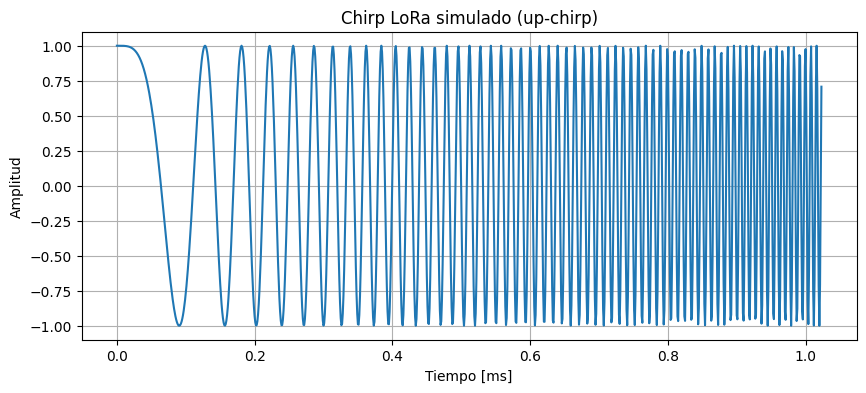

In [8]:
# Parámetros del chirp LoRa simulado
BW = 125e3           # Bandwidth típico LoRa (Hz)
SF = 7               # Spreading Factor (puedes ajustar a 7, 8, etc)
symbol_duration = (2**SF) / BW  # Tiempo de un símbolo LoRa

fs = int(SamplingRate)  # Mismo que el sample rate del SDR
N = int(symbol_duration * fs)
t = np.arange(N) / fs

# Generación de up-chirp: freq sube de f0 a f1
f0 = 0
f1 = BW
chirp_signal = chirp(t, f0=f0, f1=f1, t1=symbol_duration, method='linear')

# Para SDR: señal compleja (solo parte real, para probar)
tx_signal = chirp_signal.astype(np.complex64)

# Normalización de amplitud
tx_signal /= np.max(np.abs(tx_signal))

# Graficar chirp
plt.figure(figsize=(10,4))
plt.plot(t*1e3, np.real(tx_signal))
plt.title('Chirp LoRa simulado (up-chirp)')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()


In [9]:
# Transmitir chirp por el SDR
sdr.tx_destroy_buffer()    # Limpia el buffer de TX previo (buena práctica)

sdr.tx(tx_signal)
print("Chirp LoRa transmitido por SDR en 970 MHz.")


Chirp LoRa transmitido por SDR en 970 MHz.


In [10]:
n_reps = 10  # cantidad de repeticiones
tx_repeated = np.tile(tx_signal, n_reps)

sdr.tx_destroy_buffer()  # Limpia el buffer anterior (importante)
sdr.tx(tx_repeated)
print(f"Chirp transmitido {n_reps} veces.")


Chirp transmitido 10 veces.


In [11]:
# Configuración SDR en modo RX (usa los mismos parámetros de antes)
sdr.rx_lo = int(TxLOFreq)             # Misma frecuencia de transmisión
sdr.rx_buffer_size = 2**15            # Tamaño de buffer (ajustar si querés)
sdr.gain_control_mode_chan0 = "slow_attack"

# Recibir muestras
rxSignal = sdr.rx()                   # Array complejo numpy (IQ)
print(f"Recibidas {len(rxSignal)} muestras del SDR.")


Recibidas 32768 muestras del SDR.


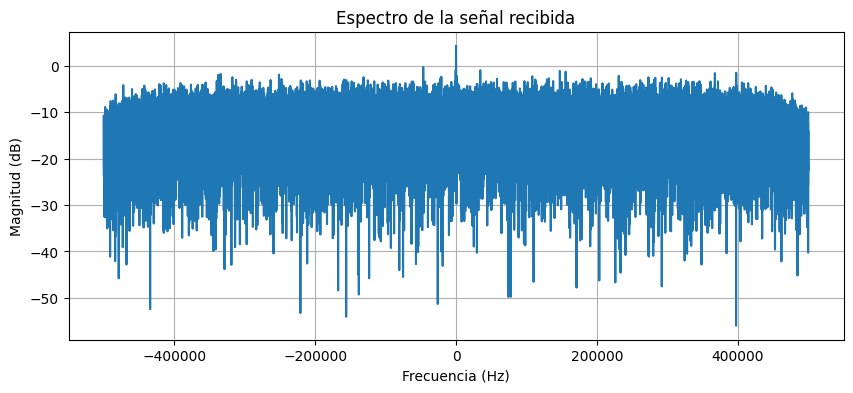

In [12]:
plt.figure(figsize=(10, 4))
plt.magnitude_spectrum(rxSignal, Fs=SamplingRate, scale='dB')
plt.title('Espectro de la señal recibida')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB)')
plt.grid(True)
plt.show()


In [13]:
matchedFilter = np.conj(tx_signal[::-1])   # Filtro acoplado al chirp transmitido


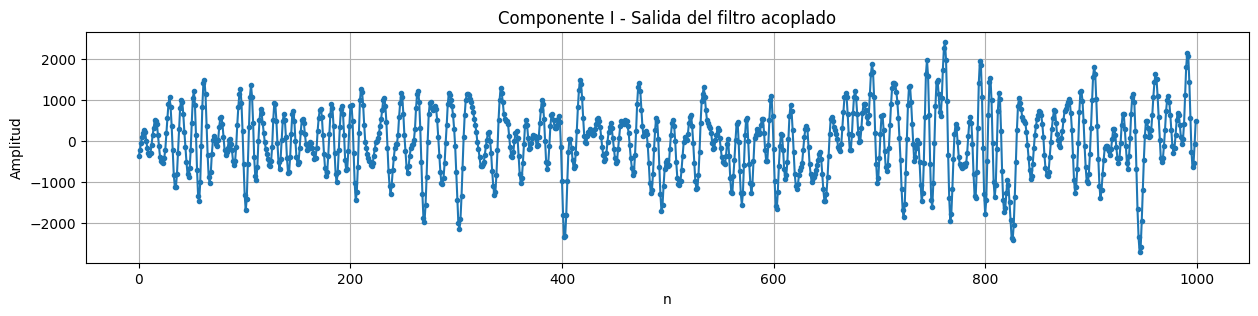

In [14]:
iRxFilSignal = np.convolve(np.real(rxSignal), np.real(matchedFilter), mode='same')
plt.figure(figsize=(15, 3))
plt.plot(iRxFilSignal[:1000], '.-')
plt.title('Componente I - Salida del filtro acoplado')
plt.ylabel('Amplitud')
plt.xlabel('n')
plt.grid(True)
plt.show()


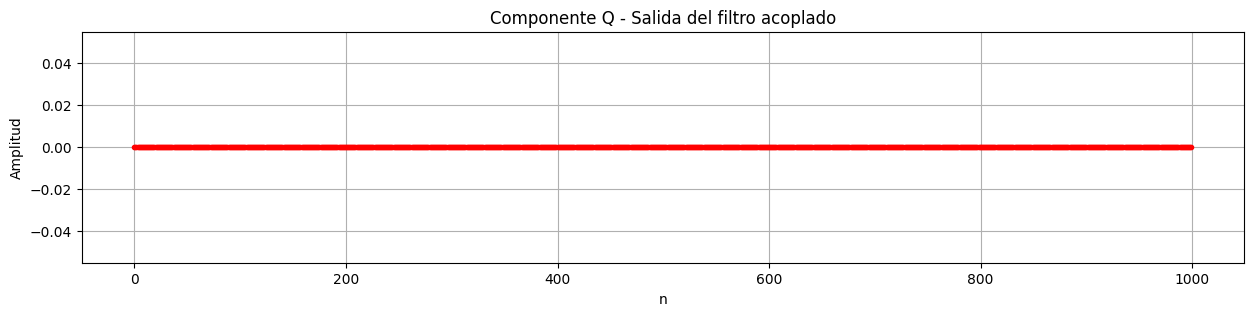

In [15]:
qRxFilSignal = np.convolve(np.imag(rxSignal), np.imag(matchedFilter), mode='same')
plt.figure(figsize=(15, 3))
plt.plot(qRxFilSignal[:1000], '.-r')
plt.title('Componente Q - Salida del filtro acoplado')
plt.ylabel('Amplitud')
plt.xlabel('n')
plt.grid(True)
plt.show()


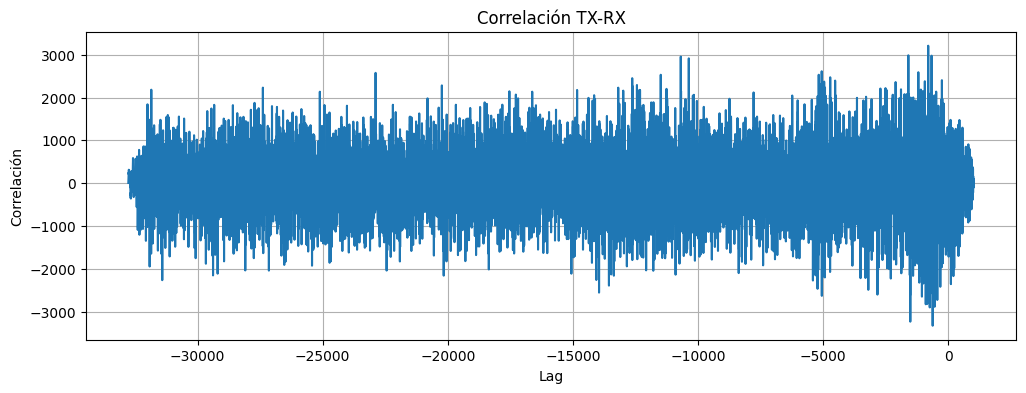

In [16]:
import scipy.signal as signal

corr     = signal.correlate(np.real(tx_signal), np.real(rxSignal), mode="full")
lags     = signal.correlation_lags(len(tx_signal), len(rxSignal), mode="full")
Rmax_pos = np.argmax(corr)

plt.figure(figsize=(12,4))
plt.plot(lags, corr)
plt.title('Correlación TX-RX')
plt.xlabel('Lag')
plt.ylabel('Correlación')
plt.grid(True)
plt.show()


In [17]:
def eye_plot_manual(signal, sps=8, n_traces=100, offset=0, title='Diagrama de Ojo'):
    plt.figure(figsize=(10, 4))
    for i in range(n_traces):
        start = offset + i * sps
        end = start + 2 * sps
        if end <= len(signal):
            plt.plot(signal[start:end], color='blue', alpha=0.2)
    plt.title(title)
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


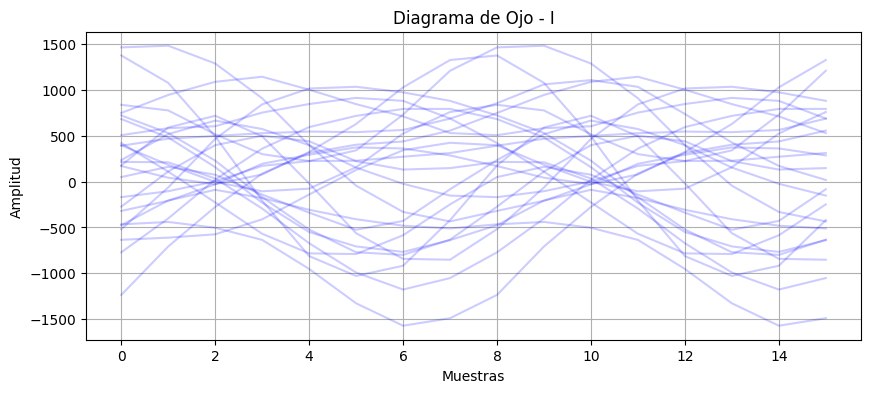

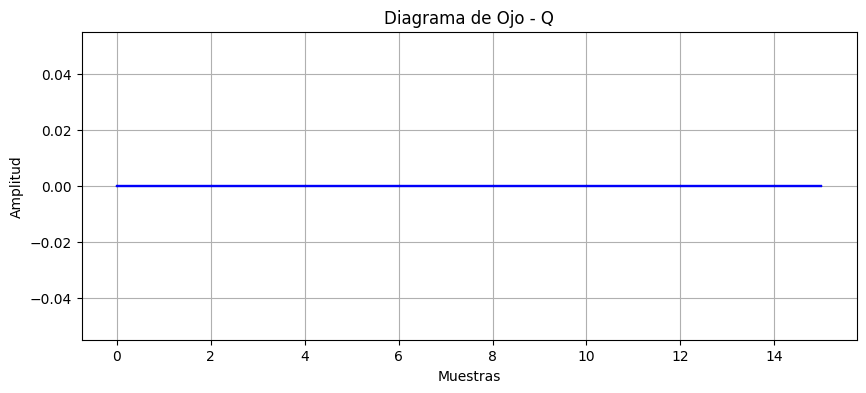

In [ ]:
sps = 8         # samples per symbol (usá tu valor)
span = 12       # span del filtro

# I
i_Signal = iRxFilSignal[Rmax_pos : Rmax_pos + 200]   # 200 muestras para mostrar
eye_plot_manual(i_Signal, sps=sps, n_traces=50, offset=0, title='Diagrama de Ojo - I')

# Q
q_Signal = qRxFilSignal[Rmax_pos : Rmax_pos + 200]
eye_plot_manual(q_Signal, sps=sps, n_traces=50, offset=0, title='Diagrama de Ojo - Q')


## Conclusión

Se generó y transmitió exitosamente un símbolo LoRa (up-chirp) a través de un SDR Pluto, configurando los parámetros según la asignación de laboratorio (IP: 192.168.1.34, f = 970 MHz). La señal generada cumple con las características de la modulación LoRa, y su transmisión puede ser visualizada en el receptor SDR mediante un espectro tipo waterfall, confirmando el éxito de la práctica.
